In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [9]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-04-06-eval:samudra_llc:Agulhas,from-4-4-26-RESUME/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [10]:
#9216,9960

In [23]:
# llc_patch = llc_patch_full.isel(time=slice(9216, 9960, 96))
# emulator_patch = emulator_patch_full.isel(time=slice(0,742,96))
extent = 8
llc_patch = llc_patch_full.isel(time=slice(9216, 9216+extent))
emulator_patch = emulator_patch_full.isel(time=slice(0,extent))

In [24]:
# Rename lat/lon to j/i
emulator_patch = emulator_patch.rename({'lat': 'j', 'lon': 'i'})

# Copy over coordinates from llc_patch
emulator_patch['XC'] = llc_patch['XC']
emulator_patch['YC'] = llc_patch['YC']
emulator_patch['rA'] = llc_patch['rA']
emulator_patch['Z'] = llc_patch['Z']

## Shear

In [ ]:
# LLC Patch
dz_llc = np.diff(llc_patch.Z.values)
dz_llc = dz_llc[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_llc = np.diff(llc_patch['U'].values, axis=1) / dz_llc
dv_dz_llc = np.diff(llc_patch['V'].values, axis=1) / dz_llc

S2_llc = du_dz_llc**2 + dv_dz_llc**2

llc_patch['S2'] = xr.DataArray(S2_llc, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [ ]:
# Emulator Patch
dz_emulator = np.diff(emulator_patch.Z.values)
dz_emulator = dz_emulator[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_emulator = np.diff(emulator_patch['U'].values, axis=1) / dz_emulator
dv_dz_emulator = np.diff(emulator_patch['V'].values, axis=1) / dz_emulator

S2_emulator = du_dz_emulator**2 + dv_dz_emulator**2

emulator_patch['S2'] = xr.DataArray(S2_emulator, dims=['time', 'k', 'j', 'i'], 
                                    coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                            'j': emulator_patch['j'], 'i': emulator_patch['i']})

In [ ]:
# Plot S2 every 2 time steps
n_times = len(llc_patch['time'])
time_step = 2
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).S2
    emulator_vis = emulator_patch.isel(time=t, k=0).S2
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels=30)
    ax1.set_title(f'LLC S2 time={t}', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels=30)
    ax2.set_title(f'Emulator S2 time={t}', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels=30)
    ax3.set_title(f'LLC - Emulator S2 time={t}', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/S2_time_diff.png')
#plt.show()
plt.close()

In [ ]:
nrows = 8  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 8, 16, 24, 32, 40]  # equally spaced through 50 depths (S2 has k=0-49)

# Equally space 15 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).S2
        
        ax = axes[row, col]
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="viridis", levels=20)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/S2_depth_time_progression.png')
#plt.show()
plt.close()

## Vorticity

In [ ]:
omega = 7.2921e-5

# LLC Patch
omega = 7.2921e-5
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

# Get grid spacing from rA (cell area) - approximate dx, dy
dx = np.sqrt(llc_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()  
U = llc_patch['U'].values
V = llc_patch['V'].values

dvdx = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dudy = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

vort_llc = dvdx - dudy

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

# Emulator Patch
omega = 7.2921e-5
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

# Get grid spacing from rA (cell area) - approximate dx, dy
dx = np.sqrt(emulator_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()  
U = emulator_patch['U'].values
V = emulator_patch['V'].values

dvdx = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dudy = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

vort_emulator = dvdx - dudy

vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]

emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

In [ ]:
# Plot vorticity every 2 time steps
n_times = len(llc_patch['time'])
time_step = 2
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).vorticity
    emulator_vis = emulator_patch.isel(time=t, k=0).vorticity
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([float(llc_vis.quantile(0.001)), float(emulator_vis.quantile(0.001))])
    vmax = np.max([float(llc_vis.quantile(0.999)), float(emulator_vis.quantile(0.999))])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels=30)
    ax1.set_title(f'LLC vorticity time={t}', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="viridis", vmin=vmin, vmax=vmax, levels=30)
    ax2.set_title(f'Emulator vorticity time={t}', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels=30)
    ax3.set_title(f'LLC - Emulator vorticity time={t}', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/vorticity_time_diff.png')
#plt.show()
plt.close()

In [ ]:
nrows = 15  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 15 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).vorticity
        
        ax = axes[row, col]
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="viridis", levels=20)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/vorticity_depth_time_progression.png')
#plt.show()
plt.close()

## W

In [ ]:
# omega = 7.2921e-5
# f_0 = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

# Z = llc_patch['Z'].values
# DEPTH_THICKNESS = np.abs(np.diff(Z))

# u_x = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
# v_y = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2
# divergence = u_x + v_y

# W_div = np.zeros_like(divergence)
# for k in range(divergence.shape[1] - 1, 0, -1):
#     W_div[:, k-1, :, :] = W_div[:, k, :, :] - divergence[:, k, :, :] * DEPTH_THICKNESS[k-1]

# W_div_normalized = W_div / f_0[np.newaxis, np.newaxis, :, :]
# W_div_normalized = np.clip(W_div_normalized, 
#                             np.nanpercentile(W_div_normalized, 1), 
#                             np.nanpercentile(W_div_normalized, 99))
# W_div_normalized = W_div_normalized / np.nanmax(np.abs(W_div_normalized))

# llc_patch['W_div'] = (('time', 'k', 'j', 'i'), W_div_normalized)

## Strain

In [ ]:
omega = 7.2921e-5
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

dx = np.sqrt(llc_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

U = llc_patch['U'].values
V = llc_patch['V'].values

u_x_llc = (np.roll(U, -1, axis=3) - np.roll(U, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
u_y_llc = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])
v_x_llc = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
v_y_llc = (np.roll(V, -1, axis=2) - np.roll(V, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)


In [ ]:
omega = 7.2921e-5
f_0_emulator= np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

dx = np.sqrt(emulator_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

U = emulator_patch['U'].values
V = emulator_patch['V'].values

u_x_emulator = (np.roll(U, -1, axis=3) - np.roll(U, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
u_y_emulator = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])
v_x_emulator = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
v_y_emulator = (np.roll(V, -1, axis=2) - np.roll(V, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

sigma_n_emulator = u_x_emulator - v_y_emulator
sigma_s_emulator = v_x_emulator + u_y_emulator
sigma_emulator = np.sqrt(sigma_n_emulator**2 + sigma_s_emulator**2)

sigma_emulator_normalized = sigma_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]

emulator_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_emulator_normalized)

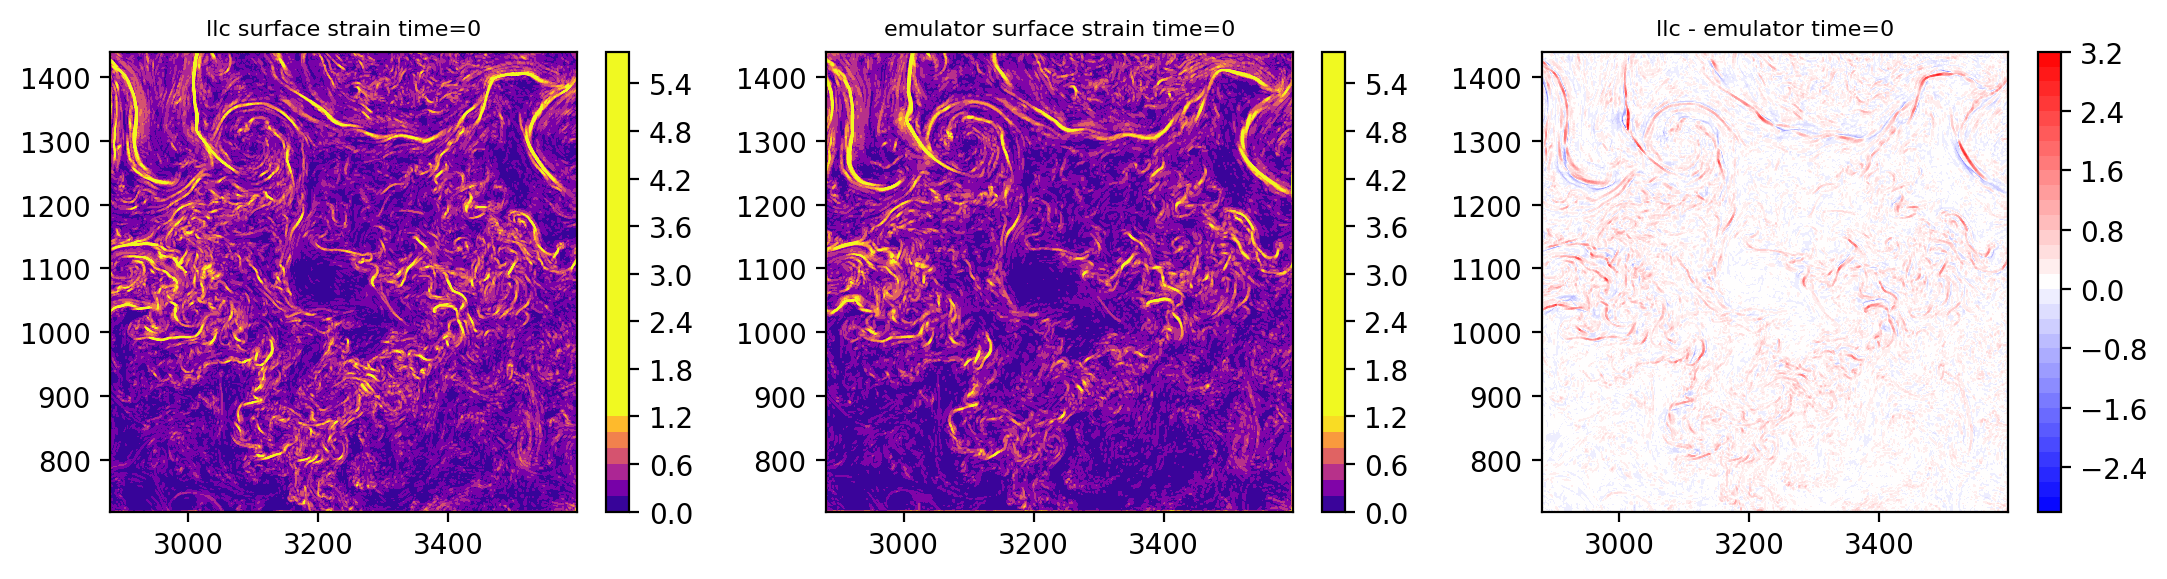

In [ ]:
llc_vis = llc_patch.isel(time=0,k=0).strain
emulator_vis = emulator_patch.isel(time=0,k=0).strain

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)
vmin_llc = 0
vmax_llc = float(llc_vis.quantile(0.99))
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=vmin_llc,vmax=vmax_llc, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=0', fontsize=8)
vmin_emulator = 0
vmax_emulator = float(emulator_vis.quantile(0.99))
cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=vmin_emulator,vmax=vmax_emulator, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface strain time=0', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Plot strain every 2 time steps
n_times = len(llc_patch['time'])
time_step = 2
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).strain
    emulator_vis = emulator_patch.isel(time=t, k=0).strain
    
    # Get shared vmin/vmax for this time step
    vmin = 0
    vmax = np.max([float(llc_vis.quantile(0.99)), float(emulator_vis.quantile(0.99))])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="plasma", vmin=vmin, vmax=vmax, levels=30)
    ax1.set_title(f'LLC strain time={t}', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="plasma", vmin=vmin, vmax=vmax, levels=30)
    ax2.set_title(f'Emulator strain time={t}', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels=30)
    ax3.set_title(f'LLC - Emulator strain time={t}', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/strain_time_diff.png')
#plt.show()
plt.close()


In [ ]:
nrows = 8  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 15 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).strain
        
        ax = axes[row, col]
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="plasma", levels=20)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/strain_depth_time_progression.png')
#plt.show()
plt.close()

## N2

In [8]:
g = 9.81
alpha = 2e-4
beta = 7.4e-4

# Reuse dz from S2 calculation (already computed)
# dz_llc = np.diff(llc_patch.Z.values)[np.newaxis, :, np.newaxis, np.newaxis]
# dz_emulator = np.diff(emulator_patch.Z.values)[np.newaxis, :, np.newaxis, np.newaxis]

# LLC Patch - simplify: g*alpha*dT/dz - g*beta*dS/dz
N2_llc = g * alpha * np.diff(llc_patch['Theta'].values, axis=1) / dz_llc - \
         g * beta * np.diff(llc_patch['Salt'].values * (35.16504 / 35), axis=1) / dz_llc

llc_patch['N2'] = xr.DataArray(N2_llc, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

# Emulator Patch
N2_emulator = g * alpha * np.diff(emulator_patch['Theta'].values, axis=1) / dz_emulator - \
              g * beta * np.diff(emulator_patch['Salt'].values * (35.16504 / 35), axis=1) / dz_emulator

emulator_patch['N2'] = xr.DataArray(N2_emulator, dims=['time', 'k', 'j', 'i'], 
                                    coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                            'j': emulator_patch['j'], 'i': emulator_patch['i']})

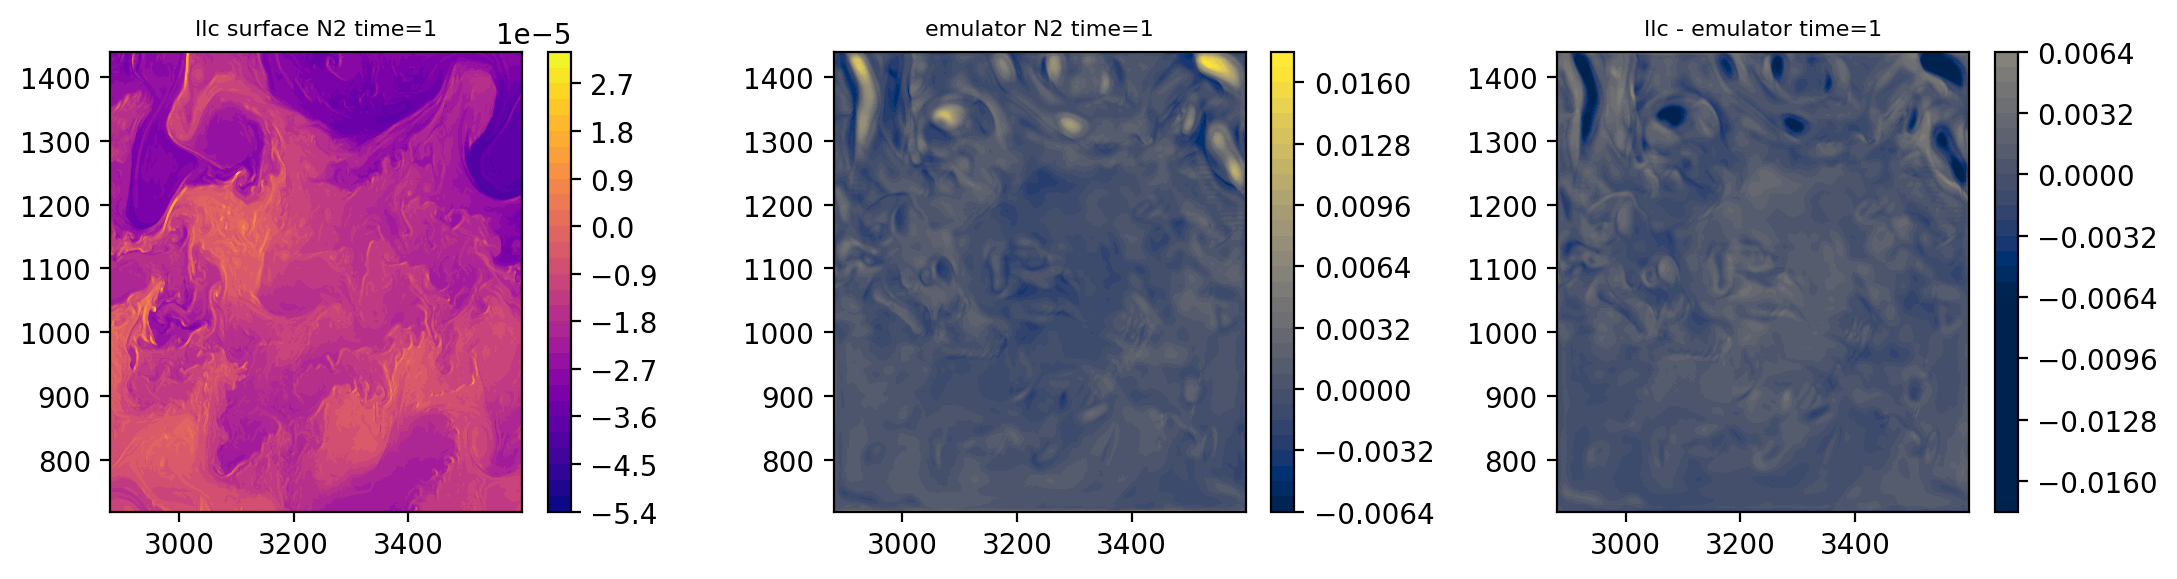

In [9]:
llc_vis = llc_patch.isel(time=1,k=0).N2
emulator_vis = emulator_patch.isel(time=1,k=0).N2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface N2 time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="cividis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator N2 time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="cividis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Plot N2 every 2 time steps
n_times = len(llc_patch['time'])
time_step = 2
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).N2
    emulator_vis = emulator_patch.isel(time=t, k=0).N2
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="cividis", vmin=vmin, vmax=vmax, levels=30)
    ax1.set_title(f'LLC N2 time={t}', fontsize=8)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="cividis", vmin=vmin, vmax=vmax, levels=30)
    ax2.set_title(f'Emulator N2 time={t}', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels=30)
    ax3.set_title(f'LLC - Emulator N2 time={t}', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/N2_time_diff.png')
#plt.show()
plt.close()

In [11]:
nrows = 8  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 15 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).N2
        
        ax = axes[row, col]
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="cividis", levels=20)
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/N2_depth_time_progression.png')
#plt.show()
plt.close()

## Ri

In [12]:
llc_Ri = llc_patch.N2 / (llc_patch.S2.isel(k=slice(0,-1)) + 1e-10)

llc_patch['Ri'] = xr.DataArray(llc_Ri, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [13]:
emulator_Ri = emulator_patch.N2 / (emulator_patch.S2.isel(k=slice(0,-1)) + 1e-10)

emulator_patch['Ri'] = xr.DataArray(emulator_Ri, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                        'j': emulator_patch['j'], 'i': emulator_patch['i']})

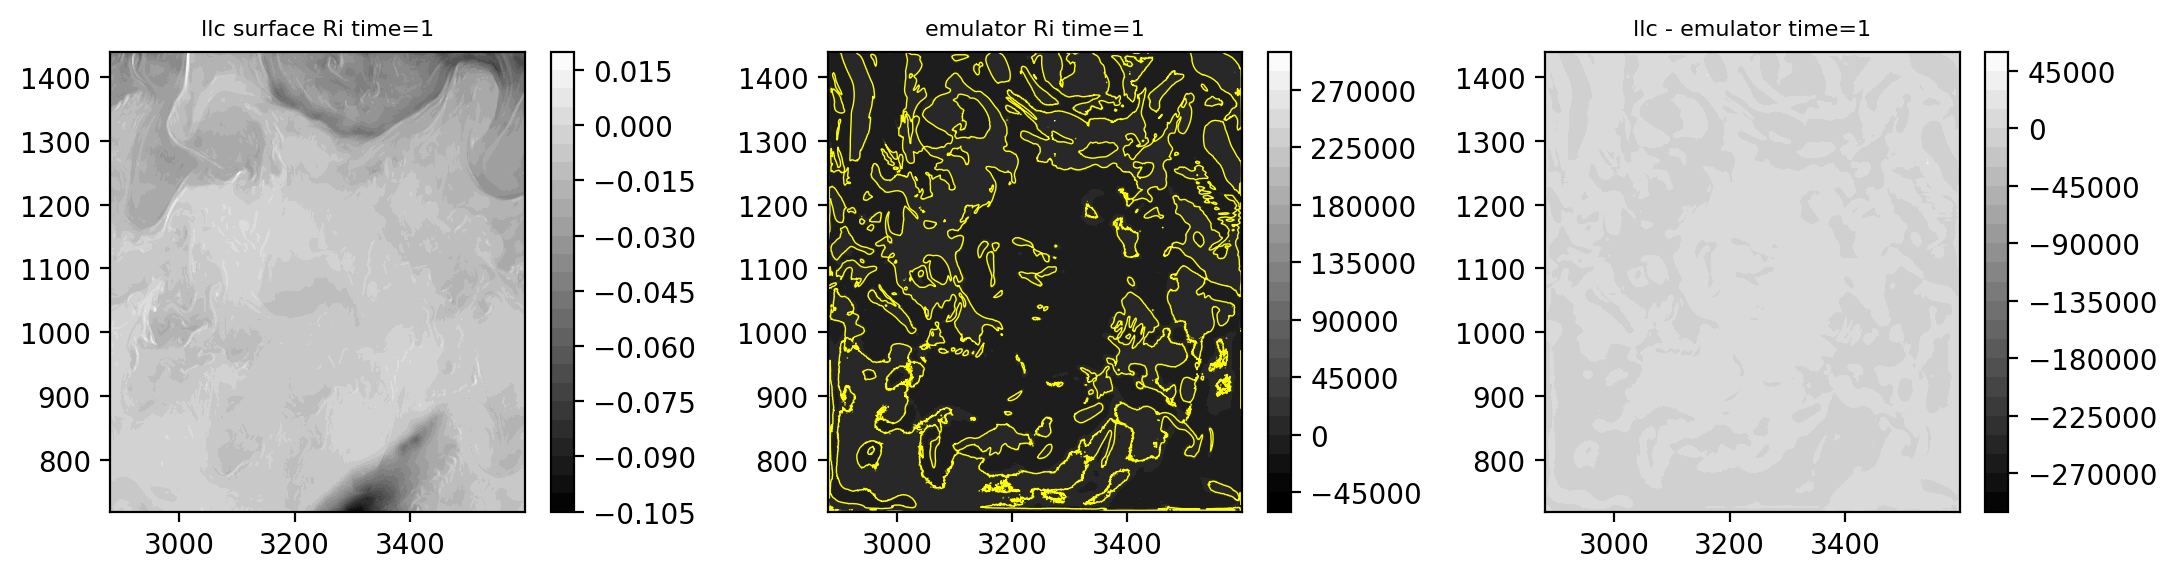

In [14]:
llc_vis = llc_patch.isel(time=1,k=0).Ri
emulator_vis = emulator_patch.isel(time=1,k=0).Ri

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="gray",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
ax1.contour(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface Ri time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="gray",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
ax2.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator Ri time=1', fontsize=8)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="gray", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

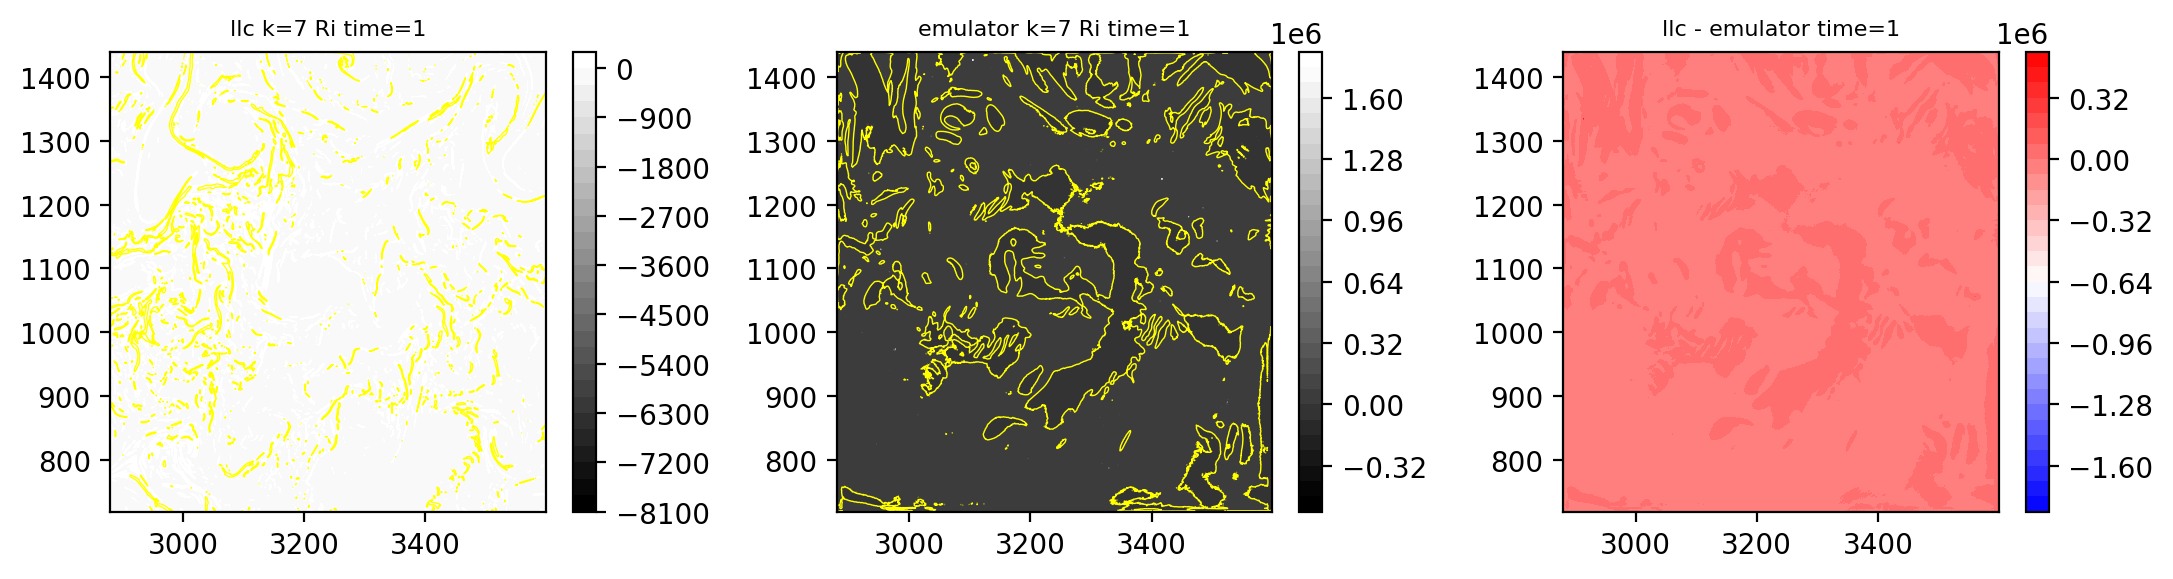

In [15]:
llc_vis = llc_patch.isel(time=1,k=9).Ri
emulator_vis = emulator_patch.isel(time=1,k=9).Ri

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="gray",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
ax1.contour(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc k=7 Ri time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="gray",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
ax2.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator k=7 Ri time=1', fontsize=8)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Plot Ri every 2 time steps
n_times = len(llc_patch['time'])
time_step = 2
time_indices = list(range(0, n_times, time_step))
nrows = len(time_indices)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3*nrows), dpi=200)

for row, t in enumerate(time_indices):
    llc_vis = llc_patch.isel(time=t, k=0).Ri
    emulator_vis = emulator_patch.isel(time=t, k=0).Ri
    
    # Get shared vmin/vmax for this time step
    vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
    vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])
    
    ax1, ax2, ax3 = axes[row, 0], axes[row, 1], axes[row, 2]
    
    cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
        llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
            cmap="gray", vmin=vmin, vmax=vmax, levels=30)
    ax1.set_title(f'LLC Ri time={t}', fontsize=8)
    ax1.contour(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
    plt.colorbar(cf1, ax=ax1)
    
    cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
            cmap="gray", vmin=vmin, vmax=vmax, levels=30)
    ax2.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
        levels=[0.25], colors='yellow', linewidths=0.5)
    ax2.set_title(f'Emulator Ri time={t}', fontsize=8)
    plt.colorbar(cf2, ax=ax2)
    
    diff = llc_vis.values - emulator_vis.values
    cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
        emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
            cmap="bwr", levels=30)
    ax3.set_title(f'LLC - Emulator Ri time={t}', fontsize=8)
    plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/Ri_time_diff.png')
#plt.show()
plt.close()

In [17]:
nrows = 8  # time samples (every 2 days)
ncols = 6   # depth samples
depth_indices = [0, 10, 20, 30, 40, 50]  # equally spaced through 50 depths

# Equally space 15 time samples across available data
n_times = len(emulator_patch['time'])
time_indices = np.linspace(0, n_times - 1, nrows, dtype=int)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2*nrows), dpi=100)

for row, t in enumerate(time_indices):
    for col, k in enumerate(depth_indices):
        emulator_vis = emulator_patch.isel(time=t, k=k).Ri
        
        ax = axes[row, col]
        
        cf = ax.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
                cmap="gray", levels=20)

        ax.contour(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
            emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis.values, \
            levels=[0.25], colors='yellow', linewidths=0.5)
        
        
        if col == ncols - 1:
            plt.colorbar(cf, ax=ax)
        
        if row == 0:
            ax.set_title(f'Depth k={k}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'time={t}', fontsize=8)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('figs/mixing/depth-time-snapshots/Ri_depth_time_progression.png')
#plt.show()
plt.close()